# `geqie-qml` training example with GEQIELayer live feature encoding

The GEQIE image encodings are calculated on the fly using the `geqie_qml.GEQIELayer`, which might be computationally expensive. This notebook demonstrates how to train a QNN using these live encodings.

In [4]:
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchinfo
from torch.utils import data as torch_data
from torchmetrics import Accuracy
from torchvision import datasets, transforms

import lightning as L
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from qiskit.circuit.library import real_amplitudes

sys.modules.pop("geqie_qml", None)
import geqie_qml

pio.templates["latex"] = pio.templates["plotly_white"].update(
    layout=dict(colorway=px.colors.qualitative.D3, font=dict(family="CMU Serif"))
)
pio.templates.default = "latex"


## Dataset configuration

In [5]:
DATASET_SIZE = 1000
VAL_SPLIT    = 0.2
BATCH_SIZE   = 32

In [6]:
transform = transforms.Compose([transforms.ToTensor()])  # (1, 28, 28) in [0, 1]

full_train = datasets.MNIST(root=".mnist", train=True,  download=True, transform=transform)
test_ds    = datasets.MNIST(root=".mnist", train=False, download=True, transform=transform)

n_val   = int(DATASET_SIZE * VAL_SPLIT)
n_train = DATASET_SIZE - n_val
train_subset, val_subset, _ = torch_data.random_split(
    full_train,
    [n_train, n_val, len(full_train) - DATASET_SIZE],
    generator=torch.Generator().manual_seed(42),
)

train_loader = torch_data.DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = torch_data.DataLoader(val_subset,   batch_size=BATCH_SIZE)
test_loader  = torch_data.DataLoader(test_ds,      batch_size=BATCH_SIZE)

print(f"Train: {n_train}  Val: {n_val}  Test: {len(test_ds)}")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:01<00:00, 9.50MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 259kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 2.44MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 4.47MB/s]

Train: 800  Val: 200  Test: 10000


## Trainer definition

In [14]:
LEARNING_RATE = 0.1

N_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5
LR_SCHEDULER_PATIENCE = 3

# "none"                – fastest; CNN is a fixed feature extractor, no quantum backprop
# "first_batch_average" – CNN trains via a single precomputed Jacobian (good compromise)
# "full"                – exact but evaluates 2×B×H×W circuits per backward step (slow)
GEQIE_GRAD_MODE = "none"

In [21]:
class VQCModel(L.LightningModule):
    def __init__(self, model: nn.Module, n_classes: int, learning_rate: float = 1e-2):
        super().__init__()
        self.save_hyperparameters(ignore=["model"])
        self.model = model
        self.train_acc = Accuracy(task="multiclass", num_classes=n_classes)
        self.val_acc   = Accuracy(task="multiclass", num_classes=n_classes)

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        x, y = batch
        log_probs = self(x)
        loss = F.nll_loss(log_probs, y)
        return loss, log_probs.argmax(dim=-1), y

    def training_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.train_acc(preds, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc",  self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("lr", self.trainer.optimizers[0].param_groups[0]["lr"], on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.val_acc(preds, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc",  self.val_acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=LR_SCHEDULER_PATIENCE,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"},
        }


In [22]:
class SqueezeChannels(nn.Module):
    """Remove the channel dimension: (B, 1, H, W) → (B, H, W)."""
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x.squeeze(1)

## Model definitions

### Config

In [23]:
N_QUBITS   = 7        # FRQI on 8×8 needs 2*ceil(log2(8))+1 = 7 qubits
N_CLASSES  = 10
N_LAYERS   = 4        # real_amplitudes reps

### Ansatz

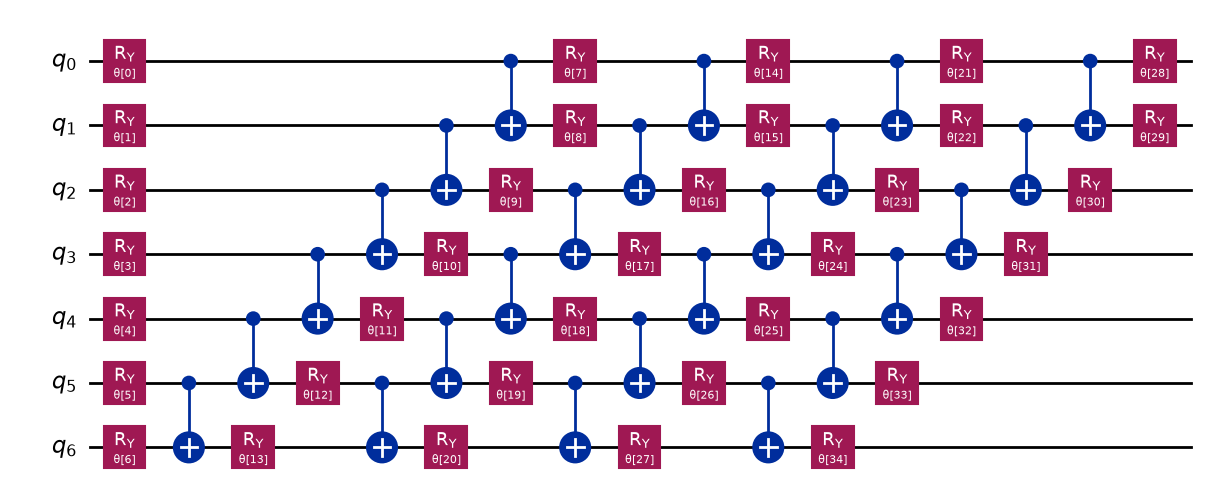

In [24]:
ansatz = real_amplitudes(N_QUBITS, reps=N_LAYERS)
ansatz.draw("mpl")

### Model 1. GEQIE → Ansatz → Softmax

In [25]:
geqie_only_model = nn.Sequential(
    nn.AdaptiveAvgPool2d((8, 8)),                                 # (B,  1, 28, 28) → (B,  1,  8,  8)
    SqueezeChannels(),                                            # (B,  1,  8,  8) → (B,  8,  8)
    geqie_qml.GEQIELayer("frqi", grad_mode=GEQIE_GRAD_MODE),      # (B,  8,  8)     → (B, 128) complex
    geqie_qml.SamplerAnsatzLayer(N_QUBITS, ansatz),               # (B, 128)        → (B, 128) probs
    nn.Linear(2 ** N_QUBITS, N_CLASSES),                          # (B, 128)        → (B,  10)
    nn.LogSoftmax(dim=-1),
)

torchinfo.summary(geqie_only_model, input_size=(BATCH_SIZE, 1, 28, 28))


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 10]                  --
├─AdaptiveAvgPool2d: 1-1                 [32, 1, 8, 8]             --
├─SqueezeChannels: 1-2                   [32, 8, 8]                --
├─GEQIELayer: 1-3                        [32, 128]                 --
├─SamplerAnsatzLayer: 1-4                [32, 128]                 35
├─Linear: 1-5                            [32, 10]                  1,290
├─LogSoftmax: 1-6                        [32, 10]                  --
Total params: 1,325
Trainable params: 1,325
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.18
Input size (MB): 0.10
Forward/backward pass size (MB): 0.04
Params size (MB): 0.01
Estimated Total Size (MB): 0.14

#### Training

In [26]:
vqc_module = VQCModel(geqie_only_model, n_classes=N_CLASSES, learning_rate=LEARNING_RATE)

trainer = L.Trainer(
    max_epochs=N_EPOCHS,
    accelerator="auto",
    log_every_n_steps=1,
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    callbacks=[
        L.pytorch.callbacks.TQDMProgressBar(leave=True),
        L.pytorch.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOPPING_PATIENCE, mode="min"),
    ],
)

trainer.fit(vqc_module, train_dataloaders=train_loader, val_dataloaders=val_loader)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | model     | Sequential         | 1.3 K  | train | 0    
1 | train_acc | MulticlassAccuracy | 0      | train | 0    
2 | val_acc   | MulticlassAccuracy | 0      | train | 0    
-----------------------------------------------------------------
1.3 K     Trainable params
0         Non-trainable params
1.3 K     Total params
0.005     Total estimated model para

Training: |                                                                                                                                                          | 0/? [00:00<?, ?it/s]
Epoch 49: 100%|███████████████████████████████████████████████████████| 25/25 [06:40<00:00,  0.06it/s, v_num=2, val_loss=0.897, val_acc=0.730, train_loss=0.580, train_acc=0.840, lr=0.025]

`Trainer.fit` stopped: `max_epochs=50` reached.


#### Results

In [27]:
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

TRAIN_COLOR, VAL_COLOR = "#1f77b4", "#ff7f0e"

fig = make_subplots(rows=1, cols=2, subplot_titles=("Loss", "Accuracy"))
for cols, col_idx in [
    (["train_loss", "val_loss"], 1),
    (["train_acc",  "val_acc"],  2),
]:
    for c in cols:
        subset = metrics.dropna(subset=[c])
        fig.add_trace(
            go.Scatter(
                x=subset["epoch"], y=subset[c], mode="lines+markers", name=c,
                line=dict(color=TRAIN_COLOR if c.startswith("train") else VAL_COLOR),
            ),
            row=1, col=col_idx,
        )
fig.update_xaxes(title_text="Epoch")
fig.update_layout(height=400, width=900)
fig.show()


Epoch 0:   0%|                                                                                                                                                    | 0/25 [5:37:59<?, ?it/s]


### Model 2 — CNN → GEQIE → Ansatz → Softmax

In [28]:
cnn = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),     # (B,  8, 28, 28)
    nn.BatchNorm2d(8),
    nn.ReLU(),
    nn.MaxPool2d(2),                               # (B,  8, 14, 14)
    nn.Conv2d(8, 1, kernel_size=3, padding=1),     # (B,  1, 14, 14)
    nn.BatchNorm2d(1),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d((8, 8)),                  # (B,  1,  8,  8)
    SqueezeChannels(),                             # (B,  8,  8)
)

cnn_model = nn.Sequential(
    cnn,
    geqie_qml.GEQIELayer("frqi", grad_mode=GEQIE_GRAD_MODE),    # (B, 8, 8)  → (B, 128) complex
    geqie_qml.SamplerAnsatzLayer(N_QUBITS, ansatz),             # (B, 128)   → (B, 128) probs
    nn.Linear(2 ** N_QUBITS, N_CLASSES),                        # (B, 128)   → (B, 10)
    nn.LogSoftmax(dim=-1),
)

torchinfo.summary(cnn_model, input_size=(BATCH_SIZE, 1, 28, 28))


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 10]                  --
├─Sequential: 1-1                        [32, 8, 8]                --
│    └─Conv2d: 2-1                       [32, 8, 28, 28]           80
│    └─BatchNorm2d: 2-2                  [32, 8, 28, 28]           16
│    └─ReLU: 2-3                         [32, 8, 28, 28]           --
│    └─MaxPool2d: 2-4                    [32, 8, 14, 14]           --
│    └─Conv2d: 2-5                       [32, 1, 14, 14]           73
│    └─BatchNorm2d: 2-6                  [32, 1, 14, 14]           2
│    └─ReLU: 2-7                         [32, 1, 14, 14]           --
│    └─AdaptiveAvgPool2d: 2-8            [32, 1, 8, 8]             --
│    └─SqueezeChannels: 2-9              [32, 8, 8]                --
├─GEQIELayer: 1-2                        [32, 128]                 --
├─SamplerAnsatzLayer: 1-3                [32, 128]                 35
├─Linear: 1-4   

#### Training

In [ ]:
vqc_module = VQCModel(cnn_model, n_classes=N_CLASSES, learning_rate=LEARNING_RATE)

trainer = L.Trainer(
    max_epochs=N_EPOCHS,
    accelerator="auto",
    log_every_n_steps=1,
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    callbacks=[
        L.pytorch.callbacks.TQDMProgressBar(leave=True),
        L.pytorch.callbacks.EarlyStopping(monitor="val_loss", patience=5, mode="min"),
    ],
)

trainer.fit(vqc_module, train_dataloaders=train_loader, val_dataloaders=val_loader)


#### Results

In [32]:
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

TRAIN_COLOR, VAL_COLOR = "#1f77b4", "#ff7f0e"

fig = make_subplots(rows=1, cols=2, subplot_titles=("Loss", "Accuracy"))
for cols, col_idx in [
    (["train_loss", "val_loss"], 1),
    (["train_acc",  "val_acc"],  2),
]:
    for c in cols:
        subset = metrics.dropna(subset=[c])
        fig.add_trace(
            go.Scatter(
                x=subset["epoch"], y=subset[c], mode="lines+markers", name=c,
                line=dict(color=TRAIN_COLOR if c.startswith("train") else VAL_COLOR),
            ),
            row=1, col=col_idx,
        )
fig.update_xaxes(title_text="Epoch")
fig.update_layout(height=400, width=900)
fig.show()
